#### **Assignment 2: Clustering and Kernels**

**Members: Cui(Cathy) Yu, Shravani Mahadeshwar, Priya Botsa, Marc Hayes, Shaonan Feng and Di Yang**

- *Course: Machine Learning 2*
- *Prof: Jan Nagler*
- *Due: 25 April 2026*

**Methodology**

**Part 1: Clustering**

**Dataset**
- Seeds dataset (UCI, ID 236) - `210` wheat kernel samples across `3` varieties: **Kama, Rosa, and Canadian**
- Chosen because the three classes form partially overlapping, roughly elliptical clusters, well-suited to compare a centroid-based method *(K-Means)* against a probabilistic one *(GMM)* and to demonstrate where a density-based method *(DBSCAN)* breaks down on uniformly distributed data.

**Clustering Algorithms**
- **K-Means:** partitions data by minimising within-cluster inertia; assumes spherical, equal-size clusters; hard assignment
- **GMM (full covariance)**: models each cluster as a multivariate Gaussian; supports elliptical boundaries and soft probabilistic membership; evaluated on BIC and AIC for model fit
- **DBSCAN**: density-based method that groups points reachable within radius `eps` and flags low-density regions as noise; makes no assumptions about cluster shape or count; included as a contrast case to demonstrate where density-based approaches break down on uniformly distributed data

**Part 2: Kernel SVM**

**Dataset**
- Heart Disease dataset (UCI, ID 45) - `303` patient records, `13` clinical features (age, cholesterol, resting BP, chest pain type, etc.)
- Binary target: **0 = no heart disease, 1 = disease** (derived from original multi-class "num" column via thresholding at > 0)
- Chosen because clinical features are expected to have nonlinear interactions, making it a meaningful testbed for kernel comparison

**Metrics**
- Two metrics were chosen to reflect opposing clinical priorities, using the general F-beta formula:

$$F_\beta = (1 + \beta^2) \cdot \frac{\text{precision} \cdot \text{recall}}{(\beta^2 \cdot \text{precision}) + \text{recall}}$$

- The **F2 score** (β=2) weights recall twice as much as precision, prioritising the correct identification of patients with heart disease. This is critical in medical diagnosis where false negatives (missed diagnoses) carry the highest risk.
- The **F0.5 score** (β=0.5) emphasises precision over recall, reducing false positives. This is relevant to avoid unnecessary stress, follow-up procedures, and medical costs for healthy patients.
- By optimizing both metrics, we evaluate model performance under two different practical priorities, reflecting real-world trade-offs in clinical decision-making.

**Kernels and Hyperparameter Search**
- Three kernels evaluated: **Linear (baseline), RBF, Polynomial**
- Linear kernel included as a baseline to assess whether nonlinear modeling adds meaningful improvement over a simpler decision boundary
- GridSearchCV with 5-fold cross-validation used for all searches
- Linear: C ∈ {0.01, 0.1, 1, 10, 100}
- RBF: C ∈ {0.01, 0.1, 1, 10, 100}, gamma ∈ {0.001, 0.01, 0.1, 1}
- Polynomial: C ∈ {0.01, 0.1, 1, 10, 100}, degree ∈ {2, 3, 4, 5}
- Each kernel optimised separately for **F2** and **F0.5**, yielding 6 trained models total

**1. Cluster the Clustering Monster**

**Importing necessary libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import cluster
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.optimize import linear_sum_assignment
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse
import warnings
from sklearn.cluster import DBSCAN
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import fbeta_score,make_scorer,classification_report
warnings.filterwarnings("ignore")
np.random.seed(42)

**Loading the dataset**

In [2]:
col_names = ["area","perimeter","compactness","length_kernel","width_kernel",
            "asymmetry_coeff","length_groove","target",]
df = pd.read_csv("data/seeds_dataset.txt", sep="\s+", header=None, names=col_names)
y_true = df["target"]
X_raw = df.drop(columns=["target"])
print("Shape:", X_raw.shape)
print("Classes:", y_true.unique())
X_raw.head()

Shape: (210, 7)
Classes: [1 2 3]


,area,perimeter,compactness,length_kernel,width_kernel,asymmetry_coeff,length_groove
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


In [3]:
print("Missing values:", X_raw.isnull().sum().sum())

Missing values: 0


**Scaling the features**

In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
print("Scaled shape:", X.shape)

Scaled shape: (210, 7)


**Plotting the first two principal components to visualize the data distribution**

Variance explained by PC1+PC2: 88.98%


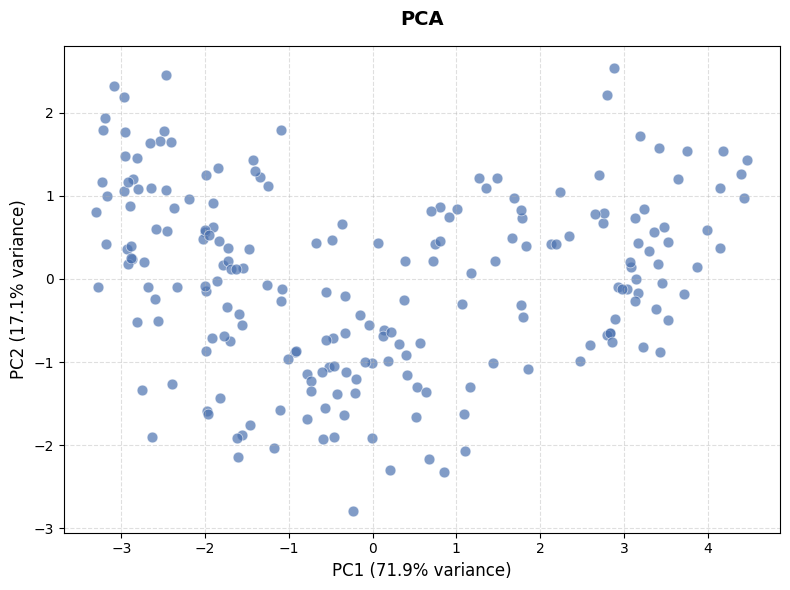

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
var_explained = pca.explained_variance_ratio_.sum()
print(f"Variance explained by PC1+PC2: {var_explained:.2%}")
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca[:, 0],X_pca[:, 1],s=60,alpha=0.7,color="#4C72B0",edgecolors="white",linewidths=0.5)
ax.set_title("PCA", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

- PC1 dominates with `71.9%` variance, meaning most meaningful differences between wheat kernels come down to a single dimension likely overall **kernel size.**
- The 2D PCA projection already captures `~89%` of the total data variance, so very little information is lost by reducing from `7` features to `2` components (for visualising the data).

**Using the Elbow Method for Hyperparameter Tuning**

Chosen K = 3


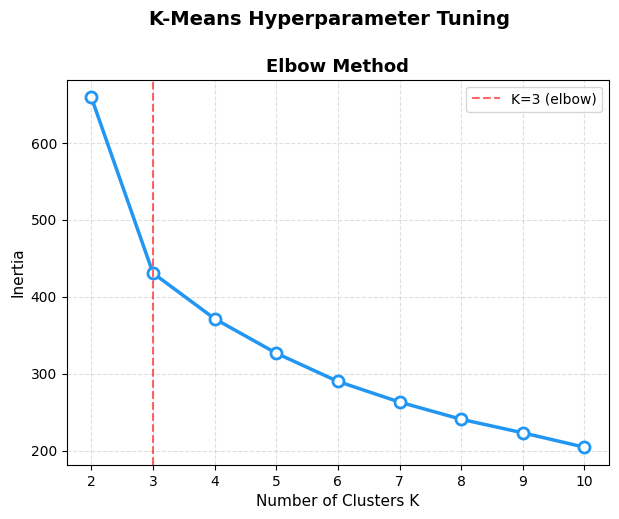

In [6]:
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = cluster.KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
fig.suptitle("K-Means Hyperparameter Tuning", fontsize=14, fontweight="bold", y=1.02)

ax.plot(K_range, inertias, "o-", color="#2196F3", linewidth=2.5, markersize=8, markerfacecolor="white", markeredgewidth=2)
ax.axvline(x=3, color="red", linestyle="--", alpha=0.6, label="K=3 (elbow)")
ax.set_title("Elbow Method", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Clusters K", fontsize=11)
ax.set_ylabel("Inertia", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.4)

best_k = 3
print(f"Chosen K = {best_k}")

**Parameter Interpretation:**
- `K=3` is the best choice as the elbow plot shows a **sharp drop in inertia from K=2 to K=3**, after which the curve flattens significantly, indicating that adding more clusters yields diminishing returns.

**Creating a mapping function to ensure consistent cluster labels across K-Means and GMM**

In [7]:
def align_labels(ref, new, n):
    """Aligning new cluster labels to reference labels via Hungarian algorithm."""
    cost = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            cost[i, j] = -np.sum((ref == i) & (new == j))
    _, col_ind = linear_sum_assignment(cost)
    return col_ind, col_ind[new]

def draw_ellipse(mean, cov, ax, color, pca, alpha=0.15, n_std=2.0):
    """Drawing a confidence ellipse for a GMM component in PCA space."""
    cov_pca = pca.components_ @ cov @ pca.components_.T
    vals, vecs = np.linalg.eigh(cov_pca)
    angle = np.degrees(np.arctan2(*vecs[:, -1][::-1]))
    width, height = 2 * n_std * np.sqrt(vals[::-1])
    ax.add_patch(
        Ellipse(xy=mean, width=width, height=height, angle=angle, color=color, alpha=alpha))
    ax.add_patch(
        Ellipse(xy=mean,width=width,height=height,angle=angle,fill=False,edgecolor=color,linewidth=2,linestyle="--"))
palette = ["#1F9EF8FF", "#F063B5", "#FDDF48"]

**K-Means Clustering**

In [8]:
kmeans = cluster.KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(X)
labels_km = kmeans.labels_
# Projecting K-Means centers to PCA space for visualization
centers_pca = pca.transform(kmeans.cluster_centers_)

**Gaussian Mixture Models**

In [9]:
gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=42)
gmm.fit(X)
labels_gmm = gmm.predict(X)
probs = gmm.predict_proba(X)
print(f"GMM converged: {gmm.converged_}")
print(f"GMM BIC: {gmm.bic(X):.2f}")
print(f"GMM AIC: {gmm.aic(X):.2f}")
col_ind, labels_gmm_aligned = align_labels(labels_km, labels_gmm, best_k)
gmm_means_aligned = gmm.means_[col_ind]
gmm_covs_aligned = gmm.covariances_[col_ind]
X_df = X_raw.copy()
X_df["cluster"] = labels_km
X_df.groupby("cluster").mean().round(3)
# Projecting GMM means to PCA space for visualization
means_pca = pca.transform(gmm_means_aligned)

GMM converged: True
GMM BIC: -69.70
GMM AIC: -427.84


- GMM converged successfully; the negative BIC (`-69.70`) and AIC (`-427.84`) 
confirm the model is a good fit, with lower (more negative) values indicating 
better fit relative to model complexity.

**DBSCAN**

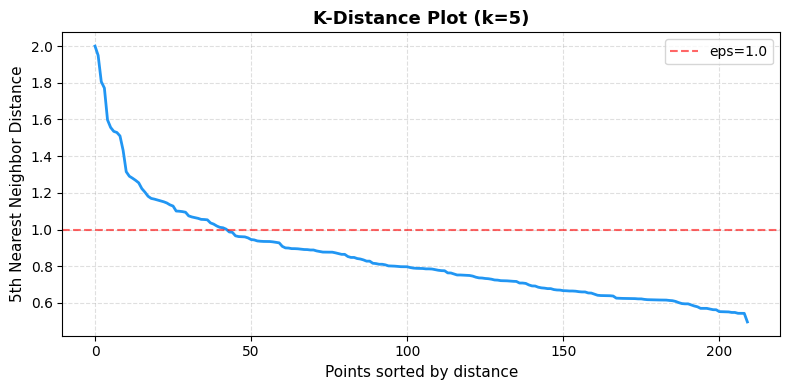

In [10]:
# Finding k-distance for k=min_samples=5 for DBSCAN eps tuning
nbrs = NearestNeighbors(n_neighbors=5).fit(X)
distances, _ = nbrs.kneighbors(X)
k_distances = np.sort(distances[:, -1])[::-1]
plt.figure(figsize=(8, 4))
plt.plot(k_distances, color="#2196F3", linewidth=2)
plt.axhline(y=1.0, color="red", linestyle="--", alpha=0.6, label="eps=1.0")
plt.title("K-Distance Plot (k=5)", fontsize=13, fontweight="bold")
plt.xlabel("Points sorted by distance", fontsize=11)
plt.ylabel("5th Nearest Neighbor Distance", fontsize=11)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

- The k-distance plot shows **no sharp elbow**, indicating the Seeds data has uniform density with no natural gaps, which is a fundamental mismatch with DBSCAN's assumptions. 
- DBSCAN requires density contrasts to separate clusters, which this dataset does not provide. 
- Therefore it is fundamentally mismatched to this data geometry, and its failure is expected regardless of eps.

In [11]:
db = DBSCAN(eps=1.0, min_samples=5)
db_labels = db.fit_predict(X)
n_clusters_db = len(set(db_labels) - {-1})
n_noise = np.sum(db_labels == -1)
print(f"DBSCAN clusters found: {n_clusters_db}")
print(f"Noise points: {n_noise}")

DBSCAN clusters found: 1
Noise points: 13


**Comparing clustering algorithms**

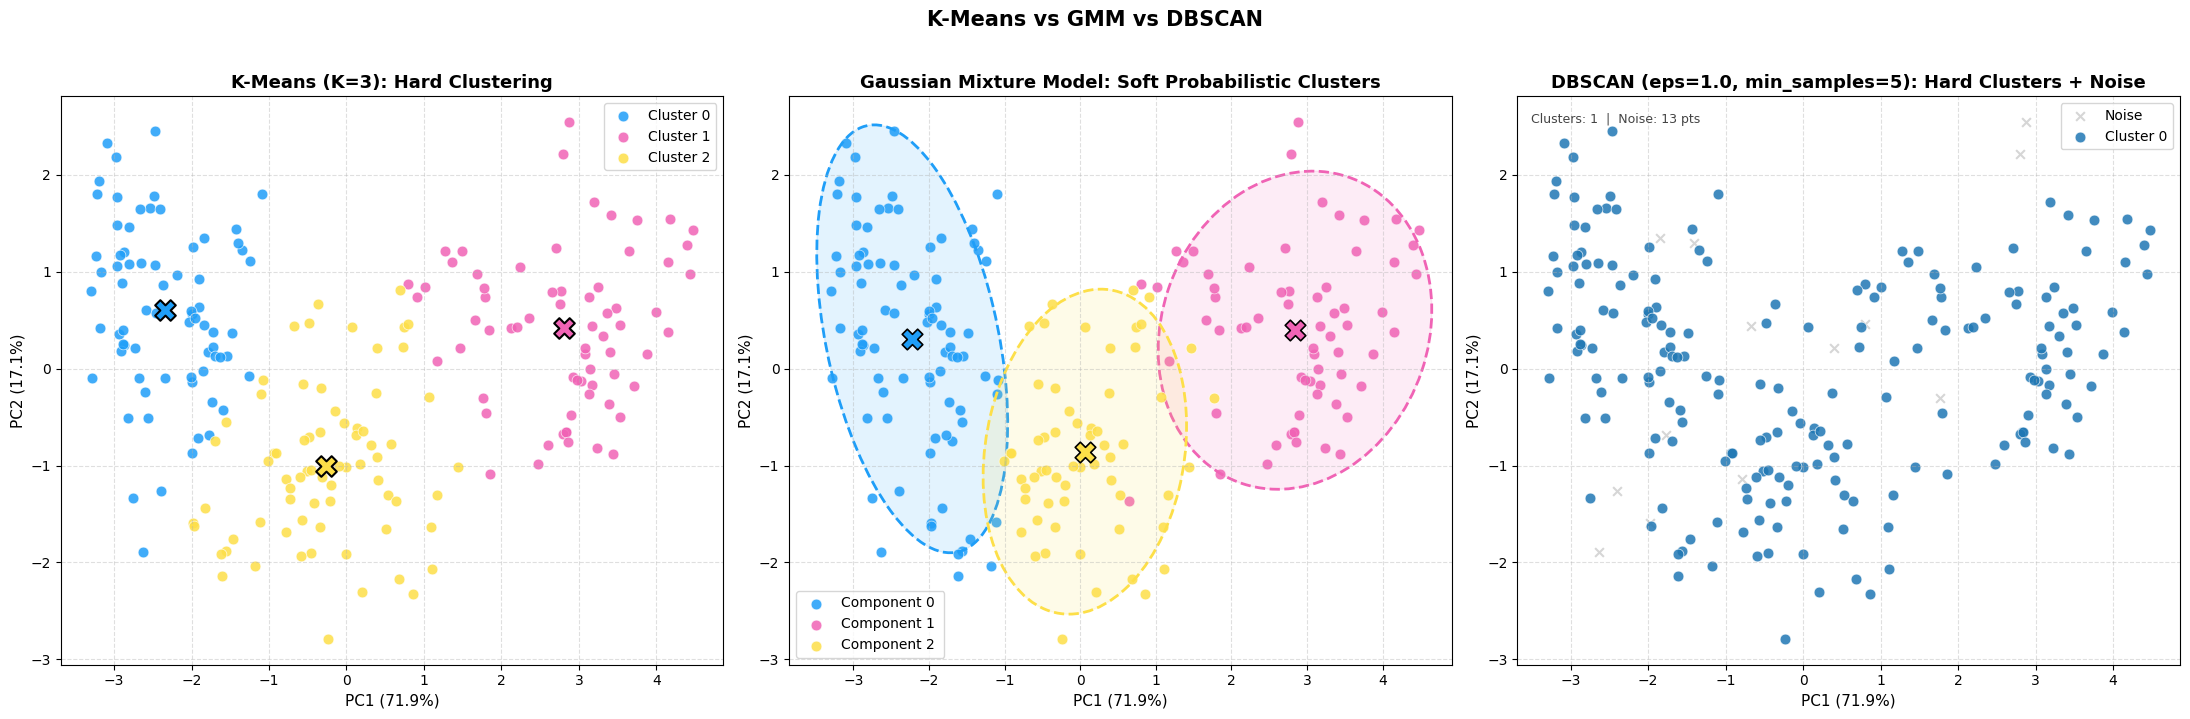

In [12]:
unique_db_labels = sorted(set(db_labels))
n_db_clusters = len([l for l in unique_db_labels if l != -1])
db_colors = cm.tab10(np.linspace(0, 0.9, max(n_db_clusters, 1)))
db_palette = {lbl: db_colors[i] for i, lbl in enumerate(l for l in unique_db_labels if l != -1)}
# Visualizing K-Means, GMM, and DBSCAN results side by side in PCA space
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("K-Means vs GMM vs DBSCAN", fontsize=15, fontweight="bold", y=1.02)
for i in range(best_k):
    mask_km = labels_km == i
    axes[0].scatter(X_pca[mask_km, 0], X_pca[mask_km, 1], s=60, alpha=0.85,
                    color=palette[i], edgecolors="white", linewidths=0.5,
                    label=f"Cluster {i}")
    axes[0].scatter(centers_pca[i, 0], centers_pca[i, 1], s=220, color=palette[i],
                    marker="X", edgecolors="black", linewidths=1.5, zorder=5)
    mask_gmm = labels_gmm_aligned == i
    axes[1].scatter(X_pca[mask_gmm, 0], X_pca[mask_gmm, 1], s=60, alpha=0.85,
                    color=palette[i], edgecolors="white", linewidths=0.5,
                    label=f"Component {i} ")
    draw_ellipse(means_pca[i], gmm_covs_aligned[i], axes[1], palette[i], pca, alpha=0.12)
    axes[1].scatter(means_pca[i, 0], means_pca[i, 1], s=220, color=palette[i],
                    marker="X", edgecolors="black", linewidths=1.2, zorder=5)
# DBSCAN 
for lbl in unique_db_labels:
    mask_db = db_labels == lbl
    if lbl == -1:
        axes[2].scatter(X_pca[mask_db, 0], X_pca[mask_db, 1], s=40, alpha=0.4,
                        color="#999999", marker="x", label="Noise")
    else:
        axes[2].scatter(X_pca[mask_db, 0], X_pca[mask_db, 1], s=60, alpha=0.85,
                        color=db_palette[lbl], edgecolors="white", linewidths=0.5,
                        label=f"Cluster {lbl}")
axes[2].text(0.02, 0.97, f"Clusters: {n_db_clusters}  |  Noise: {n_noise} pts",
             transform=axes[2].transAxes, fontsize=9, va="top", color="#444444")

for ax, title in zip(axes, [f"K-Means (K={best_k}): Hard Clustering",
                              "Gaussian Mixture Model: Soft Probabilistic Clusters",
                              f"DBSCAN (eps={db.eps}, min_samples={db.min_samples}): Hard Clusters + Noise"]):
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=11)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

**Clustering Performance Evaluation using Silhouette Score**

In [13]:
print("KMeans silhouette:", round(silhouette_score(X, labels_km), 4))
print("GMM silhouette   :", round(silhouette_score(X, labels_gmm), 4))
# Calculating silhouette for DBSCAN excluding noise points (-1 labels)
mask_valid = db_labels != -1
if mask_valid.sum() > 1 and len(set(db_labels[mask_valid])) > 1:
    db_sil = round(silhouette_score(X[mask_valid], db_labels[mask_valid]), 4)
    print(f"DBSCAN silhouette (excl. noise): {db_sil}")
else:
    print(f"DBSCAN silhouette: undefined (only {len(set(db_labels[mask_valid]))} cluster found)")
# print("DBSCAN silhouette (with noise):", round(silhouette_score(X, db_labels), 4))

KMeans silhouette: 0.4007
GMM silhouette   : 0.3625
DBSCAN silhouette: undefined (only 1 cluster found)


**Conclusion**

- **K-Means** scores highest `(0.40)` as clusters are compact and well-separated, confirming it is the best fit for this dataset
- **Gaussian Mixture Model** scores slightly lower `(0.36)` with soft boundaries introducing minor overlap between components, but still recovers the `3` varieties reliably
- **DBSCAN** produces an undefined silhouette score as it collapses all points into a single cluster, failing to detect any structure due to the absence of density gaps in the data.

Overall, **K-Means** is the recommended algorithm for the Seeds dataset as it achieves the **highest silhouette score**, **recovers all `3` wheat varieties correctly**, and its assumption of spherical evenly-sized clusters aligns naturally with the true underlying class structure

**2. Kernels**

**Loading the datatset**

In [14]:
from ucimlrepo import fetch_ucirepo
heart_disease = fetch_ucirepo(id=45)

In [15]:
# metadata of the dataset
# print(heart_disease.metadata)
X = heart_disease.data.features
y = heart_disease.data.targets
# display variable information to understand the features and target
heart_disease.variables

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,NaN,years,no
1,sex,Feature,Categorical,Sex,NaN,NaN,no
2,cp,Feature,Categorical,NaN,NaN,NaN,no
3,trestbps,Feature,Integer,NaN,resting blood pressure (on admission to the ho...,mm Hg,no
4,chol,Feature,Integer,NaN,serum cholestoral,mg/dl,no
5,fbs,Feature,Categorical,NaN,fasting blood sugar > 120 mg/dl,NaN,no
6,restecg,Feature,Categorical,NaN,NaN,NaN,no
7,thalach,Feature,Integer,NaN,maximum heart rate achieved,NaN,no
8,exang,Feature,Categorical,NaN,exercise induced angina,NaN,no
9,oldpeak,Feature,Integer,NaN,ST depression induced by exercise relative to ...,NaN,no


**Pre-processing the data**

In [16]:
# Drop rows with missing values
X_hd = heart_disease.data.features.copy()
y_hd = heart_disease.data.targets.copy()
X_hd = X_hd.dropna()
y_hd = y_hd.loc[X_hd.index]
# Binary classification: 0 = no disease, 1 = disease (num > 0)
y_binary = (y_hd["num"] > 0).astype(int)
# Scale features
scaler_hd = StandardScaler()
X_scaled = scaler_hd.fit_transform(X_hd)
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binary, test_size=0.2, random_state=42, stratify=y_binary)
print("Train size:", X_train.shape, "  Test size:", X_test.shape)
print("Class distribution (train):", y_train.value_counts().to_dict())

Train size: (237, 13)   Test size: (60, 13)
Class distribution (train): {0: 128, 1: 109}


**Defining f2_scorer and f05_scorer**

In [17]:
f2_scorer = make_scorer(fbeta_score, beta=2)
f05_scorer = make_scorer(fbeta_score, beta=0.5)
print("F2 scorer:", f2_scorer)
print("F0.5 scorer:", f05_scorer)

F2 scorer: make_scorer(fbeta_score, response_method='predict', beta=2)
F0.5 scorer: make_scorer(fbeta_score, response_method='predict', beta=0.5)


- We expect the relationship between clinical features and heart disease **not to be linearly separable**, so *RBF and polynomial kernels* are used to capture complex decision boundaries. 

- We include a **linear kernel** as a baseline to assess whether nonlinear modeling adds meaningful improvement.

**Baseline SVC (linear kernel)**
- **C** controls the trade-off between a wider margin and fewer misclassifications. 

*High C gives a stricter boundary while low C gives a softer margin.*

In [18]:
# Hyperparameter grid for linear SVC
param_grid_linear = {"C": [0.01, 0.1, 1, 10, 100]}
# optimize for F2 score
gs_linear_f2 = GridSearchCV(
    SVC(kernel="linear", random_state=42),
    param_grid_linear,
    cv=5,
    scoring=f2_scorer,
    return_train_score=False,
)
gs_linear_f2.fit(X_train, y_train)
best_linear_f2 = gs_linear_f2.best_estimator_
y_pred_linear_f2 = best_linear_f2.predict(X_test)
print("=== Linear SVC optimized for F2 ===")
print("Best params (linear):", gs_linear_f2.best_params_)
print("Test F2  :", round(fbeta_score(y_test, y_pred_linear_f2, beta=2), 4))
print("Test F0.5:", round(fbeta_score(y_test, y_pred_linear_f2, beta=0.5), 4))
print(
    "\n",
    classification_report(
        y_test, y_pred_linear_f2, target_names=["No Disease", "Disease"]),)


=== Linear SVC optimized for F2 ===
Best params (linear): {'C': 10}
Test F2  : 0.8029
Test F0.5: 0.8594

               precision    recall  f1-score   support

  No Disease       0.83      0.91      0.87        32
     Disease       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



In [19]:
# optimize for F0.5 score
gs_linear_f05 = GridSearchCV(
    SVC(kernel="linear", random_state=42),
    param_grid_linear,
    cv=5,
    scoring=f05_scorer,
    return_train_score=False,
)
gs_linear_f05.fit(X_train, y_train)

best_linear_f05 = gs_linear_f05.best_estimator_
y_pred_linear_f05 = best_linear_f05.predict(X_test)

print("=== Linear SVC optimized for F0.5 ===")
print("Best params:", gs_linear_f05.best_params_)
print("Test F2   :", round(fbeta_score(y_test, y_pred_linear_f05, beta=2), 4))
print("Test F0.5 :", round(fbeta_score(y_test, y_pred_linear_f05, beta=0.5), 4))

print(
    "\n",
    classification_report(
        y_test, y_pred_linear_f05, target_names=["No Disease", "Disease"]),)


=== Linear SVC optimized for F0.5 ===
Best params: {'C': 0.01}
Test F2   : 0.7778
Test F0.5 : 0.875

               precision    recall  f1-score   support

  No Disease       0.81      0.94      0.87        32
     Disease       0.91      0.75      0.82        28

    accuracy                           0.85        60
   macro avg       0.86      0.84      0.85        60
weighted avg       0.86      0.85      0.85        60



**RBF Kernel**

- **gamma** controls how far the influence of a single training point reaches. 

*High gamma gives a tight localized boundary with overfitting risk, low gamma gives a smoother broader boundary.*

In [20]:
# Hyperparameter grid for RBF kernel 
param_grid_rbf = {"C": [0.01, 0.1, 1, 10, 100], "gamma": [0.001, 0.01, 0.1, 1]}

gs_rbf_f2 = GridSearchCV(
    estimator=SVC(kernel="rbf", random_state=42),
    param_grid=param_grid_rbf,
    scoring=f2_scorer,
    cv=5,
    n_jobs=-1,
    refit=True
) 

# optimize for F2
gs_rbf_f2.fit(X_train, y_train)

best_rbf_f2 = gs_rbf_f2.best_estimator_
y_pred_rbf_f2 = best_rbf_f2.predict(X_test)

print("=== RBF optimized for F2 ===")
print("Best params:", gs_rbf_f2.best_params_)
print("Test F2   :", round(fbeta_score(y_test, y_pred_rbf_f2, beta=2), 4))
print("Test F0.5 :", round(fbeta_score(y_test, y_pred_rbf_f2, beta=0.5), 4))

print(
    "\n",
    classification_report(
        y_test, y_pred_rbf_f2, target_names=["No Disease", "Disease"]),)


=== RBF optimized for F2 ===
Best params: {'C': 10, 'gamma': 0.1}
Test F2   : 0.8273
Test F0.5 : 0.8456

               precision    recall  f1-score   support

  No Disease       0.85      0.88      0.86        32
     Disease       0.85      0.82      0.84        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



In [21]:
gs_rbf_f05 = GridSearchCV(
    estimator=SVC(kernel="rbf", random_state=42),
    param_grid=param_grid_rbf,
    scoring=f05_scorer,
    cv=5,
    n_jobs=-1,
    refit=True
)

# optimize for F0.5
gs_rbf_f05.fit(X_train, y_train)

best_rbf_f05 = gs_rbf_f05.best_estimator_
y_pred_rbf_f05 = best_rbf_f05.predict(X_test)

print("=== RBF optimized for F0.5 ===")
print("Best params:", gs_rbf_f05.best_params_)
print("Test F2   :", round(fbeta_score(y_test, y_pred_rbf_f05, beta=2), 4))
print("Test F0.5 :", round(fbeta_score(y_test, y_pred_rbf_f05, beta=0.5), 4))

print(
    "\n",
    classification_report(
        y_test, y_pred_rbf_f05, target_names=["No Disease", "Disease"]),)


=== RBF optimized for F0.5 ===
Best params: {'C': 1, 'gamma': 0.01}
Test F2   : 0.8088
Test F0.5 : 0.8871

               precision    recall  f1-score   support

  No Disease       0.83      0.94      0.88        32
     Disease       0.92      0.79      0.85        28

    accuracy                           0.87        60
   macro avg       0.88      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60



**Polynomial Kernel**

- **degree** controls the complexity of the polynomial decision boundary. 

*Higher degree means a more complex boundary with overfitting risk*

In [22]:
# Hyperparameter grid for polynomial kernel
param_grid_poly = {"C": [0.01, 0.1, 1, 10, 100], "degree": [2, 3, 4, 5]}

# optimize for F2
gs_poly_f2 = GridSearchCV(
    estimator=SVC(kernel="poly", random_state=42),
    param_grid=param_grid_poly,
    scoring=f2_scorer,
    cv=5,
    n_jobs=-1,
    refit=True
)

gs_poly_f2.fit(X_train, y_train)

best_poly_f2 = gs_poly_f2.best_estimator_
y_pred_poly_f2 = best_poly_f2.predict(X_test)

print("=== Polynomial SVC optimized for F2 ===")
print("Best params:", gs_poly_f2.best_params_)
print("Test F2   :", round(fbeta_score(y_test, y_pred_poly_f2, beta=2), 4))
print("Test F0.5 :", round(fbeta_score(y_test, y_pred_poly_f2, beta=0.5), 4))

print(
    "\n",
    classification_report(
        y_test, y_pred_poly_f2, target_names=["No Disease", "Disease"]),)

=== Polynomial SVC optimized for F2 ===
Best params: {'C': 10, 'degree': 3}
Test F2   : 0.7609
Test F0.5 : 0.7955

               precision    recall  f1-score   support

  No Disease       0.79      0.84      0.82        32
     Disease       0.81      0.75      0.78        28

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60



In [23]:
# optimize for F0.5
gs_poly_f05 = GridSearchCV(
    estimator=SVC(kernel="poly", random_state=42),
    param_grid=param_grid_poly,
    scoring=f05_scorer,
    cv=5,
    n_jobs=-1,
    refit=True
)

gs_poly_f05.fit(X_train, y_train)

best_poly_f05 = gs_poly_f05.best_estimator_
y_pred_poly_f05 = best_poly_f05.predict(X_test)

print("=== Polynomial SVC optimized for F0.5 ===")
print("Best params:", gs_poly_f05.best_params_)
print("Test F2   :", round(fbeta_score(y_test, y_pred_poly_f05, beta=2), 4))
print("Test F0.5 :", round(fbeta_score(y_test, y_pred_poly_f05, beta=0.5), 4))

print(
    "\n",
    classification_report(
        y_test, y_pred_poly_f05, target_names=["No Disease", "Disease"]),)

=== Polynomial SVC optimized for F0.5 ===
Best params: {'C': 100, 'degree': 5}
Test F2   : 0.7778
Test F0.5 : 0.875

               precision    recall  f1-score   support

  No Disease       0.81      0.94      0.87        32
     Disease       0.91      0.75      0.82        28

    accuracy                           0.85        60
   macro avg       0.86      0.84      0.85        60
weighted avg       0.86      0.85      0.85        60



**Plotting train vs test F2 and F0.5 for all kernels across hyperparameters**

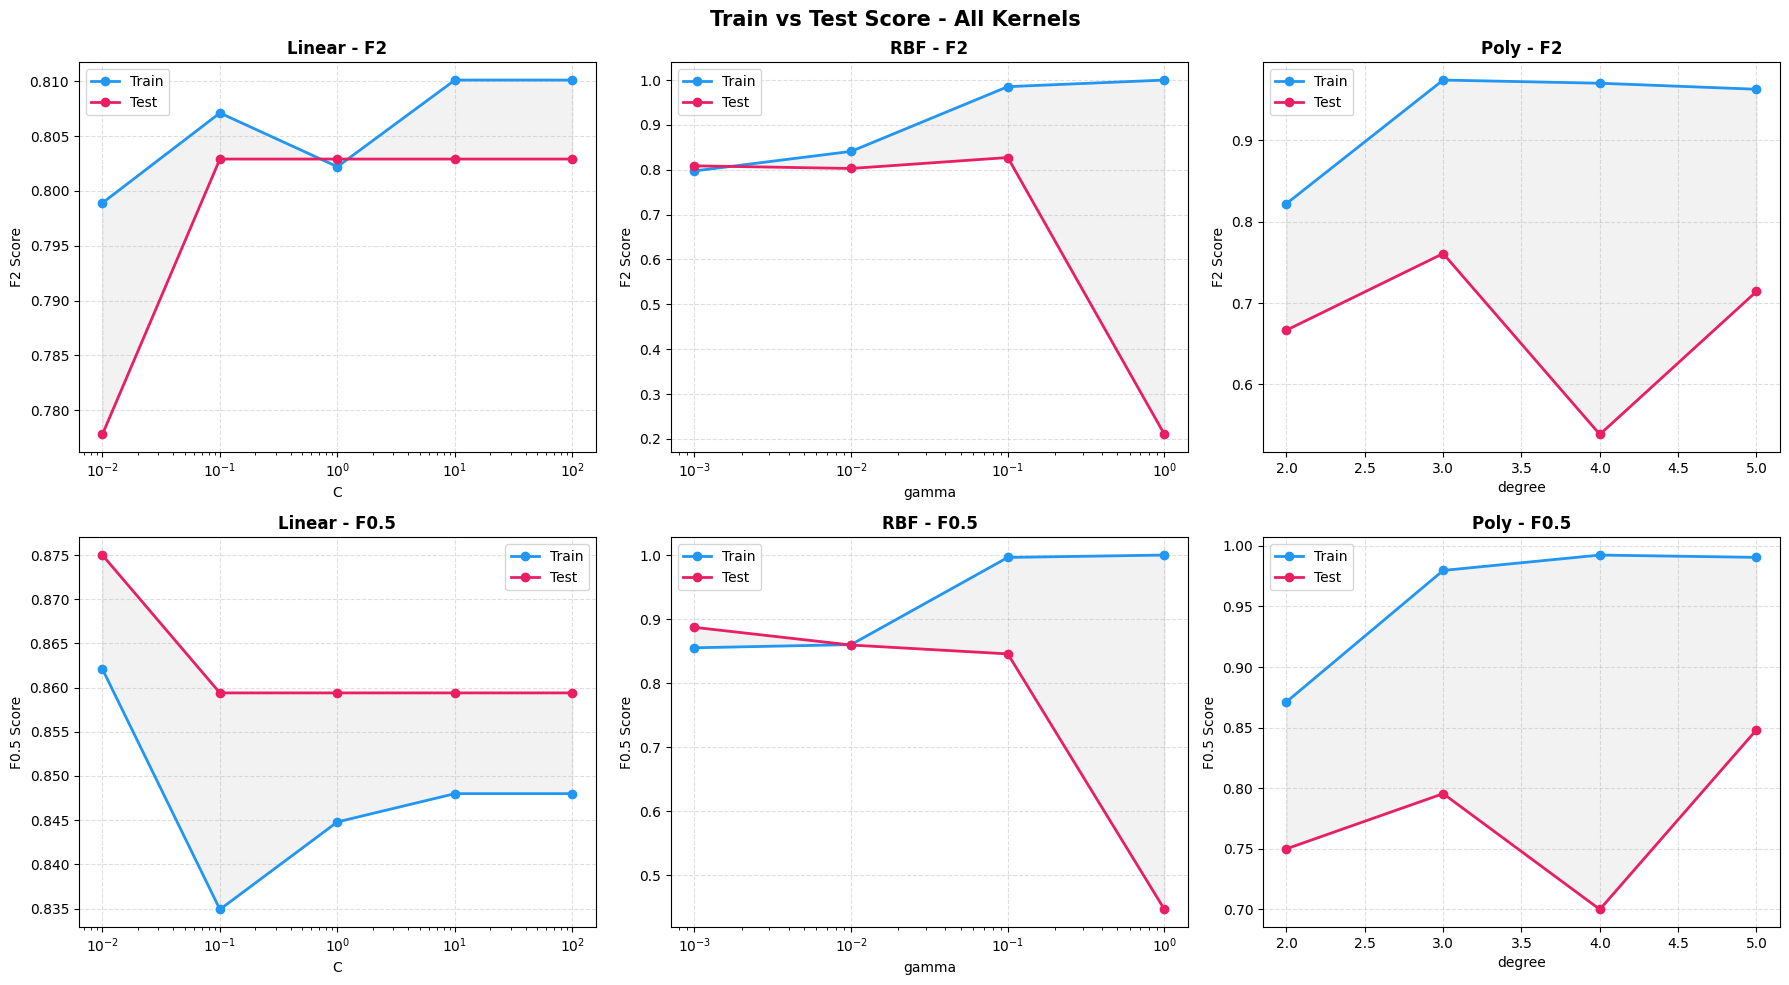

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Train vs Test Score - All Kernels", fontsize=15, fontweight="bold")

kernel_setups = [
    ("Linear", "C",      [0.01, 0.1, 1, 10, 100],
     [SVC(kernel="linear", C=c, random_state=42) for c in [0.01, 0.1, 1, 10, 100]]),
    ("RBF",    "gamma",  [0.001, 0.01, 0.1, 1],
     [SVC(kernel="rbf", C=10, gamma=g, random_state=42) for g in [0.001, 0.01, 0.1, 1]]),
    ("Poly",   "degree", [2, 3, 4, 5],
     [SVC(kernel="poly", C=10, degree=d, random_state=42) for d in [2, 3, 4, 5]]),]

for col, (name, param_name, param_vals, svcs) in enumerate(kernel_setups):
    for row, (beta, metric_name) in enumerate([(2, "F2"), (0.5, "F0.5")]):
        train_scores, test_scores = [], []
        for svc in svcs:
            svc.fit(X_train, y_train)
            train_scores.append(round(fbeta_score(y_train, svc.predict(X_train), beta=beta), 4))
            test_scores.append(round(fbeta_score(y_test,  svc.predict(X_test),  beta=beta), 4))
        ax = axes[row, col]
        ax.plot(param_vals, train_scores, "o-", color="#2196F3", linewidth=2, label="Train")
        ax.plot(param_vals, test_scores,  "o-", color="#E91E63", linewidth=2, label="Test")
        ax.fill_between(param_vals, train_scores, test_scores, alpha=0.1, color="gray")
        ax.set_title(f"{name} - {metric_name}", fontsize=12, fontweight="bold")
        ax.set_xlabel(param_name, fontsize=10)
        ax.set_ylabel(f"{metric_name} Score", fontsize=10)
        ax.set_xscale("log" if param_name in ("C", "gamma") else "linear")
        ax.legend(fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

**Train vs Test Gap Analysis**

**Linear Kernel**
- F2: Train and test scores are close across all C values `(~0.80)`, confirming **no overfitting**. The model generalizes well, consistent with the dataset being near-linearly separable.
- F0.5: Test *exceeds* train at low C `(C=0.01)`, **indicating underfitting at high regularization**. Both stabilize around `0.86` after C=0.1, sweet spot is low C.

**RBF Kernel**
- F2: Train and test track closely at low gamma, but at `gamma=1.0` train approaches 1.0 while test collapses to ~0.20 indicating **severe overfitting**. Optimal **gamma=0.1** before the divergence.
- F0.5: Same pattern, gamma=1.0 causes the model to memorize training data, destroying generalization. Confirms gamma must stay ≤ 0.1.

**Polynomial Kernel**
- F2 & F0.5: Both show a large and growing gap between train and test as degree increases.
- At degree=4, test F2 hits its minimum `(~0.55)` while train stays near 1.0 indicating **maximum overfitting**. `degree=3` is the only stable point, which is why GridSearch selected it.
- Polynomial is highly sensitive to degree and prone to overfitting, unlike RBF which degrades only at extreme gamma.

**Model Evaluation**

In [25]:
models = [
    ("Linear", "F2",   gs_linear_f2,  best_linear_f2,  y_pred_linear_f2),
    ("Linear", "F0.5", gs_linear_f05, best_linear_f05, y_pred_linear_f05),
    ("RBF",    "F2",   gs_rbf_f2,     best_rbf_f2,     y_pred_rbf_f2),
    ("RBF",    "F0.5", gs_rbf_f05,    best_rbf_f05,    y_pred_rbf_f05),
    ("Poly",   "F2",   gs_poly_f2,    best_poly_f2,    y_pred_poly_f2),
    ("Poly",   "F0.5", gs_poly_f05,   best_poly_f05,   y_pred_poly_f05)]
rows = []
for kernel, metric, gs, _, y_pred in models:
    rows.append({
        "Kernel":        kernel,
        "Optimized For": metric,
        "Best Params":   str(gs.best_params_),
        "Test F2":       round(fbeta_score(y_test, y_pred, beta=2), 4),
        "Test F0.5":     round(fbeta_score(y_test, y_pred, beta=0.5), 4)})
df_results = pd.DataFrame(rows)
df_results

,Kernel,Optimized For,Best Params,Test F2,Test F0.5
0,Linear,F2,{'C': 10},0.8029,0.8594
1,Linear,F0.5,{'C': 0.01},0.7778,0.8750
2,RBF,F2,"{'C': 10, 'gamma': 0.1}",0.8273,0.8456
3,RBF,F0.5,"{'C': 1, 'gamma': 0.01}",0.8088,0.8871
4,Poly,F2,"{'C': 10, 'degree': 3}",0.7609,0.7955
5,Poly,F0.5,"{'C': 100, 'degree': 5}",0.7778,0.8750


**Visualizing decision boundaries in PCA-reduced 2D space**

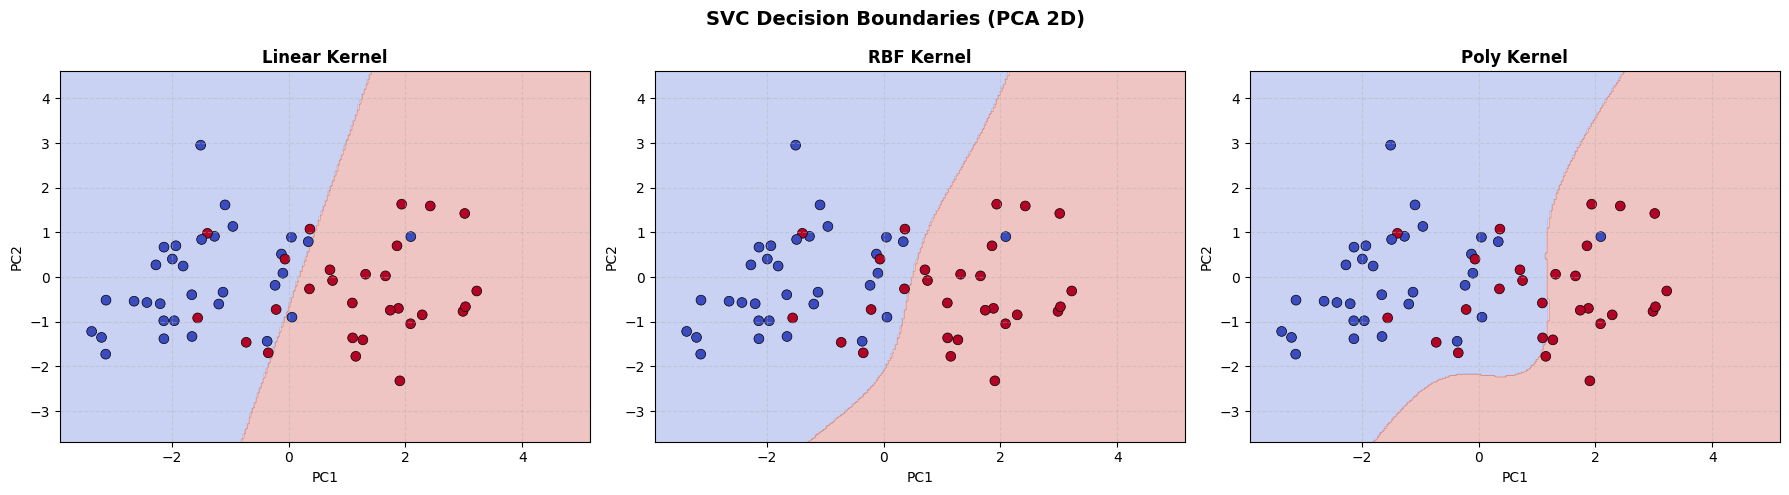

In [26]:
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train)
X_test_2d  = pca_2d.transform(X_test)
kernel_configs = [
    ("Linear", SVC(kernel="linear", C=10,  random_state=42)),
    ("RBF",    SVC(kernel="rbf",    C=10,  gamma=0.1, random_state=42)),
    ("Poly",   SVC(kernel="poly",   C=10,  degree=3,  random_state=42)),]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SVC Decision Boundaries (PCA 2D)", fontsize=14, fontweight="bold")
x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
for ax, (name, svc) in zip(axes, kernel_configs):
    svc.fit(X_train_2d, y_train)
    zz = svc.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap="coolwarm")
    ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test,
               cmap="coolwarm", edgecolors="k", linewidths=0.5, s=50)
    ax.set_title(f"{name} Kernel", fontsize=12, fontweight="bold")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

**Conclusion**

- The evaluation results show that the **RBF kernel consistently achieves the best performance across both metrics**.
- It attains the highest **F2 score** with `C=10`, `gamma=0.1`, and the highest **F0.5 score** with `C=1`, `gamma=0.01`, highlighting the trade-off between recall and precision.

- The *linear kernel provides competitive results, suggesting that the dataset exhibits a partially linear structure*. However, it is consistently outperformed by the RBF kernel, indicating that nonlinear relationships are still present.
- The *polynomial kernel yields the weakest performance across both metrics*, likely due to its sensitivity to the choice of degree and potential overfitting at higher degrees.

**Take-home message**

**Task 1: Clustering**
- Choosing the right clustering algorithm matters more than tuning its parameters as *DBSCAN* completely fails here because the data geometry does not match its assumptions.

- *K-Means*, despite its simplicity, can outperform more complex probabilistic models like *GMM* when clusters are compact, spherical, and balanced.

- *Silhouette score* is a reliable unsupervised guide for algorithm selection when ground truth is unavailable.

**Task 2: Kernels**
- The most complex model is not necessarily the best one for the data, sometimes simple models outperform complex ones.

- There is a trade-off between F2 and F0.5 scores, where optimizing for *F2 minimises false negatives (missed diagnoses)* while *F0.5 minimises false positives (healthy patients incorrectly flagged)*, and the choice should reflect the clinical cost of each error type.